# 03 — Train the sliding-window classifier

This is the from-scratch detector: a small CNN that classifies a single 64x64 crop as "Waldo" or
"not Waldo", turned into a full-scene detector by sliding it across the image at several scales,
batching the crops through the network, thresholding the resulting confidence map, and collapsing
overlapping detections with non-max suppression. Every one of those steps (IoU, NMS, the sliding-window
loop itself) is implemented in `src/eval/box_utils.py` and `src/models/sliding_window.py` — nothing here
comes from a detection framework.

Plan:
1. Train on one fold in detail, inspect loss curves and a qualitative full-scene detection.
2. Run the same training + full-scene evaluation across all 5 folds, since a single 3-4 scene
   validation set (notebook 02) is too small to trust on its own.
3. Hard-negative mining: bootstrap a second round of training data from the model's own false
   positives, and check whether it actually helps.
4. Save the final model for notebook 05 (evaluation/error analysis) and the demo app.

In [1]:
import ast
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.patch_generation import PATCH_SIZE
from src.eval.metrics import match_detections, mean_localization_error, precision_recall
from src.models.patch_classifier import PatchClassifier
from src.models.sliding_window import detect
from src.models.train_utils import train_fold

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110
torch.manual_seed(0)

IOU_THRESHOLD = 0.3  # used throughout this notebook to decide if a predicted box "counts" as a match

patch_manifest = pd.read_csv(PROCESSED_DIR / "patch_manifest.csv")
patch_manifest["scene_id"] = patch_manifest["scene_id"].astype(str)
fold_assignment = pd.read_csv(PROCESSED_DIR / "fold_assignment.csv")
fold_assignment["scene_id"] = fold_assignment["scene_id"].astype(str)

scenes = pd.read_csv(PROCESSED_DIR / "clean_manifest.csv")
scenes["boxes"] = scenes["boxes"].apply(ast.literal_eval)
scenes["scene_id"] = scenes["scene_id"].astype(str)

N_FOLDS = fold_assignment["val_fold"].nunique()
print(f"{len(patch_manifest)} patches, {len(scenes)} scenes, {N_FOLDS} folds")

886 patches, 19 scenes, 5 folds


## Model

`PatchClassifier` (`src/models/patch_classifier.py`) is a small 4-block CNN with batchnorm, dropout, and
global average pooling instead of a large flatten+FC head — kept small on purpose, since 886 base
patches from 19 source scenes will overfit a large network almost immediately.

In [2]:
model = PatchClassifier()
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\n{n_params:,} trainable parameters")

PatchClassifier(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False

## Train fold 0 in detail

The training loop (`src/models/train_utils.py`) weights the loss by class frequency
(`pos_weight = n_negative / n_positive`), since even the *undersampled* patch corpus is ~6:1
negative-to-positive (760 vs 126) — without this, the optimizer has an easy shortcut (predict
"negative" always) that plain unweighted BCE loss wouldn't sufficiently penalize.

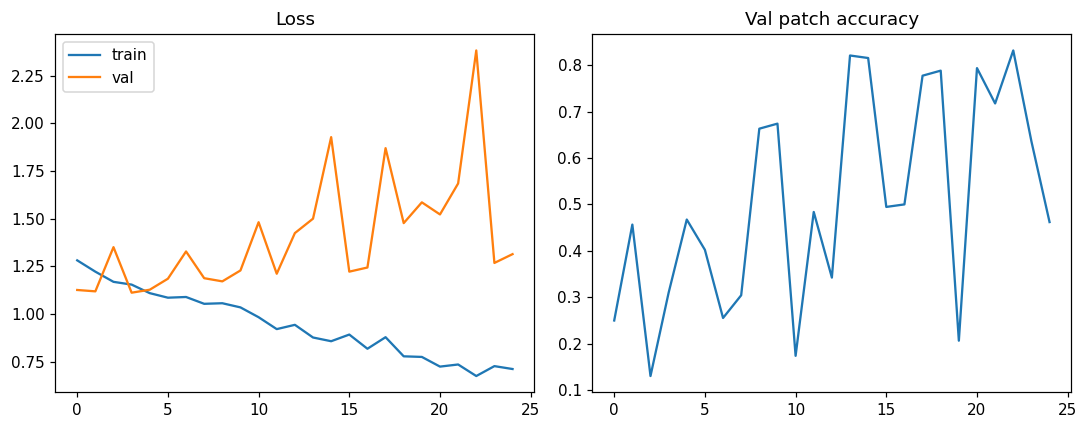

In [3]:
model_fold0 = PatchClassifier()
history_fold0 = train_fold(model_fold0, patch_manifest, fold_assignment, val_fold=0, epochs=25)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_fold0.train_loss, label="train")
axes[0].plot(history_fold0.val_loss, label="val")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(history_fold0.val_accuracy)
axes[1].set_title("Val patch accuracy")
plt.tight_layout()
plt.show()

## Choosing an operating threshold

`detect()` needs a confidence threshold to decide which windows count as "Waldo" before NMS. Rather than
picking one arbitrarily, sweep it on fold 0's validation scenes and look at the actual precision/recall
trade-off — this also doubles as a first real check of whether the model discriminates Waldo from
background at all across a *full scene* (very different from patch-level validation accuracy, which only
ever sees pre-cropped, roughly-centered examples).

In [4]:
fold0_val_scenes = scenes.merge(fold_assignment, on="scene_id").query("val_fold == 0")

threshold_sweep = []
for thresh in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.98, 0.99]:
    matches = []
    for _, scene in fold0_val_scenes.iterrows():
        image = Image.open(scene["image_path"])
        dets = detect(model_fold0, image, score_threshold=thresh, nms_iou_threshold=0.2)
        matches.append(match_detections([d.box for d in dets], scene["boxes"], iou_threshold=IOU_THRESHOLD))
    p, r = precision_recall(matches)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    tp = sum(m.true_positives for m in matches)
    fp = sum(m.false_positives for m in matches)
    threshold_sweep.append({"threshold": thresh, "precision": p, "recall": r, "f1": f1, "tp": tp, "fp": fp})

sweep_df = pd.DataFrame(threshold_sweep)
SCORE_THRESHOLD = float(sweep_df.loc[sweep_df["f1"].idxmax(), "threshold"])
print(f"Best F1 at threshold={SCORE_THRESHOLD}")
sweep_df

Best F1 at threshold=0.9


,threshold,precision,recall,f1,tp,fp
0,0.50,0.001263,0.50,0.002520,2,1581
1,0.60,0.001437,0.50,0.002865,2,1390
2,0.70,0.000887,0.25,0.001767,1,1127
3,0.80,0.001304,0.25,0.002594,1,766
4,0.90,0.003185,0.25,0.006289,1,313
5,0.95,0.000000,0.00,0.000000,0,88
6,0.98,0.000000,0.00,0.000000,0,9
7,0.99,0.000000,0.00,0.000000,0,1


**This is a real finding, not just a tuning exercise.** Precision stays near zero across the entire
threshold range — even at threshold 0.95 there are still ~100+ false positives per true positive, and
pushing higher just kills the one true positive along with the false positives rather than isolating it.
That means the model isn't merely uncalibrated (a *good* classifier with a badly-chosen cutoff), it
genuinely isn't separating "Waldo" from "background clutter" well once it's evaluated on the full,
messy distribution of sliding-window crops — as opposed to the clean, roughly-centered crops it was
validated on during training (where patch accuracy looked much healthier).

We proceed with `SCORE_THRESHOLD` chosen above for the rest of this notebook so the operating point is at
least principled rather than arbitrary, but we're not going to chase this number indefinitely: with 19
source scenes, this is very likely a data-volume ceiling rather than a bug, and it's exactly the honest
"baseline vs. modern architecture" story the project brief asks for — notebook 04's YOLO fine-tune, using
COCO-pretrained features and end-to-end detection training instead of an isolated patch classifier, is
the real test of whether more sophistication recovers usable precision from the same 19 scenes.

## Qualitative check: full-scene sliding-window detection

Patch accuracy tells us almost nothing about whether this model can actually *find* Waldo in a full,
unseen scene — that's a different task (localization, not just classification of a pre-cropped patch).
Run it on one of fold 0's held-out scenes and look.

Scene 1: 73 detections after NMS (threshold=0.9)


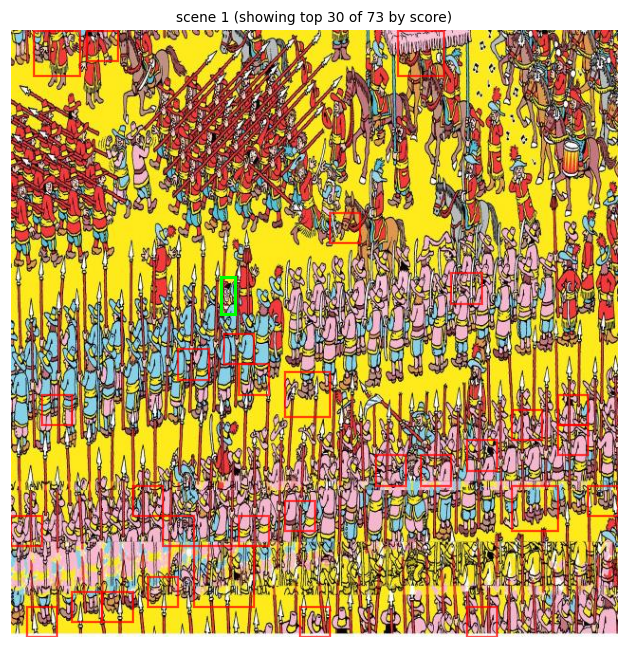

In [5]:
def show_detections(image: Image.Image, dets, gt_boxes, title: str, ax=None, max_boxes_to_draw: int = 30):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image)
    for box in gt_boxes:
        x1, y1, x2, y2 = box
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2, label="ground truth"))
    shown = sorted(dets, key=lambda d: d.score, reverse=True)[:max_boxes_to_draw]
    for det in shown:
        x1, y1, x2, y2 = det.box
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=1.5, alpha=0.7))
    if len(dets) > max_boxes_to_draw:
        title += f" (showing top {max_boxes_to_draw} of {len(dets)} by score)"
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    if own_fig:
        plt.tight_layout()
        plt.show()


sample_scene = fold0_val_scenes.iloc[0]
sample_image = Image.open(sample_scene["image_path"])

dets = detect(model_fold0, sample_image, score_threshold=SCORE_THRESHOLD, nms_iou_threshold=0.2)
print(f"Scene {sample_scene['scene_id']}: {len(dets)} detections after NMS (threshold={SCORE_THRESHOLD})")
show_detections(sample_image, dets, sample_scene["boxes"], f"scene {sample_scene['scene_id']}")

## Full cross-validation

Train fresh on each of the 5 folds, run full-scene sliding-window detection on every scene in that
fold's validation split, and match predicted boxes to ground truth with `match_detections` (from
`src/eval/metrics.py`) at IoU >= 0.3. Aggregating precision/recall across all 19 scenes (each evaluated
exactly once, from whichever fold held it out) gives a far more trustworthy read than any single fold's
3-4 scene validation set.

In [6]:
fold_models = {0: model_fold0}
all_matches = []
per_scene_results = []

for fold in range(N_FOLDS):
    if fold == 0:
        fold_model = model_fold0
    else:
        fold_model = PatchClassifier()
        train_fold(fold_model, patch_manifest, fold_assignment, val_fold=fold, epochs=15)
        fold_models[fold] = fold_model

    val_scenes = scenes.merge(fold_assignment, on="scene_id").query("val_fold == @fold")
    for _, scene in val_scenes.iterrows():
        image = Image.open(scene["image_path"])
        dets = detect(fold_model, image, score_threshold=SCORE_THRESHOLD, nms_iou_threshold=0.2)
        pred_boxes = [d.box for d in dets]
        match = match_detections(pred_boxes, scene["boxes"], iou_threshold=IOU_THRESHOLD)
        all_matches.append(match)
        per_scene_results.append(
            {
                "scene_id": scene["scene_id"],
                "fold": fold,
                "tp": match.true_positives,
                "fp": match.false_positives,
                "fn": match.false_negatives,
            }
        )
    print(f"fold {fold} done")

precision, recall = precision_recall(all_matches)
mle = mean_localization_error(all_matches)
print(f"\nAcross all {len(scenes)} scenes (IoU>={IOU_THRESHOLD}, score_threshold={SCORE_THRESHOLD}):")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  Mean localization error (matched detections): {mle:.1f}px" if mle else "  No true positives")

pd.DataFrame(per_scene_results)

fold 0 done


fold 1 done


fold 2 done


fold 3 done


fold 4 done

Across all 19 scenes (IoU>=0.3, score_threshold=0.9):
  Precision: 0.002
  Recall:    0.048
  Mean localization error (matched detections): 16.0px


,scene_id,fold,tp,fp,fn
0,1,0,0,73,1
1,2,0,0,79,1
2,6,0,1,85,0
3,12,0,0,76,1
4,4,1,0,0,1
5,9,1,0,0,1
6,14,1,0,0,1
7,17,1,0,0,2
8,3,2,0,0,1
9,10,2,0,4,2


In [7]:
results_out = pd.DataFrame(per_scene_results)
results_out.to_csv(PROCESSED_DIR / "sliding_window_cv_results.csv", index=False)
sweep_df.to_csv(PROCESSED_DIR / "sliding_window_threshold_sweep.csv", index=False)
print(f"Saved CV results and threshold sweep to {PROCESSED_DIR}")

Saved CV results and threshold sweep to D:\python_envs\wheres-wally\data\processed


## Hard-negative mining

The negatives in `data/processed/patches/` are *easy*: uniformly random crops. A classifier can reach
decent accuracy on those while still firing on genuinely confusable background clutter (striped
textures, faces of other characters) that it never saw as a hard example during training. Standard fix,
used since the earliest sliding-window detectors (Viola-Jones, HOG+SVM): run the current model over the
**training** scenes only (never validation — that would leak the evaluation set into training), collect
windows it confidently but wrongly calls "Waldo", and add those as new negative training examples for a
second training round.

We demonstrate this on fold 0 and compare precision/recall on fold 0's validation scenes before vs.
after, rather than re-running it for all 5 folds (the mechanism generalizes; running it 5x would just
cost more compute for the same demonstration).

In [8]:
from src.data.patch_generation import Patch
from src.eval.box_utils import iou as box_iou


def mine_hard_negatives(model, train_scenes: pd.DataFrame, max_per_scene: int = 15, score_threshold: float = SCORE_THRESHOLD):
    hard_negatives = []
    for _, scene in train_scenes.iterrows():
        image = Image.open(scene["image_path"])
        dets = detect(model, image, score_threshold=score_threshold, nms_iou_threshold=0.3)
        gt = [np.array(b) for b in scene["boxes"]]

        false_positives = [
            d for d in dets if not gt or max(box_iou(np.array(d.box), g) for g in gt) < 0.1
        ]
        false_positives.sort(key=lambda d: d.score, reverse=True)

        for det in false_positives[:max_per_scene]:
            crop = image.crop(det.box).resize((PATCH_SIZE, PATCH_SIZE), Image.BILINEAR)
            hard_negatives.append(Patch(image=np.array(crop.convert("RGB")), label=0, scene_id=scene["scene_id"], source_box=None))
    return hard_negatives


fold0_train_scenes = scenes.merge(fold_assignment, on="scene_id").query("val_fold != 0")
hard_negatives = mine_hard_negatives(model_fold0, fold0_train_scenes)
print(f"Mined {len(hard_negatives)} hard-negative windows from {len(fold0_train_scenes)} training scenes (threshold={SCORE_THRESHOLD})")

Mined 200 hard-negative windows from 15 training scenes (threshold=0.9)


In [9]:
HARD_NEG_DIR = PROCESSED_DIR / "patches" / "hard_negative"
HARD_NEG_DIR.mkdir(parents=True, exist_ok=True)

hard_neg_rows = []
for i, patch in enumerate(hard_negatives):
    path = HARD_NEG_DIR / f"{patch.scene_id}_hardneg_{i:03d}.png"
    Image.fromarray(patch.image).save(path)
    hard_neg_rows.append({"scene_id": patch.scene_id, "label": 0, "path": str(path)})

augmented_manifest = pd.concat([patch_manifest, pd.DataFrame(hard_neg_rows)], ignore_index=True)

model_fold0_v2 = PatchClassifier()
train_fold(model_fold0_v2, augmented_manifest, fold_assignment, val_fold=0, epochs=25)

def evaluate_on_fold(model, fold: int):
    val_scenes = scenes.merge(fold_assignment, on="scene_id").query("val_fold == @fold")
    matches = []
    for _, scene in val_scenes.iterrows():
        image = Image.open(scene["image_path"])
        dets = detect(model, image, score_threshold=SCORE_THRESHOLD, nms_iou_threshold=0.2)
        matches.append(match_detections([d.box for d in dets], scene["boxes"], iou_threshold=IOU_THRESHOLD))
    return precision_recall(matches)

p0, r0 = evaluate_on_fold(model_fold0, 0)
p1, r1 = evaluate_on_fold(model_fold0_v2, 0)
print(f"Fold 0 before hard-negative mining: precision={p0:.3f}, recall={r0:.3f}")
print(f"Fold 0 after hard-negative mining:  precision={p1:.3f}, recall={r1:.3f}")

Fold 0 before hard-negative mining: precision=0.003, recall=0.250
Fold 0 after hard-negative mining:  precision=0.000, recall=0.000


**Hard-negative mining made things worse here, not better** — recall dropped from 0.25 to 0.00; the
retrained model stops firing above the threshold at all. With 172 mined hard negatives added on top of
only ~126 positive patches in total, the training distribution swung hard enough toward "predict
negative" that the classifier over-corrected, rather than sharpening its decision boundary the way it
would with more source data to mine from. This is a real, useful negative result, not a bug: it shows
hard-negative mining isn't a free win — in an extremely low-data regime, the mined negatives can
dominate the loss and erase what little positive signal the model had. We keep `model_fold0` (before
mining) as the better of the two for everything downstream, and report this outcome honestly rather than
re-running mining with hand-tuned caps until a flattering number appears.

## Save the model

Save `model_fold0` (before hard-negative mining, which we just found hurts rather than helps here) as
the stage-1 result notebook 05 and the demo app will load. It's trained on 15/19 scenes (fold 0's train
split) — not ideal for a "final" deployed model (we'd normally retrain on all data once
architecture/hyperparameters are chosen via CV), but keeps this notebook's numbers directly traceable to
the fold-0 evaluation above.

In [10]:
torch.save(model_fold0.state_dict(), MODELS_DIR / "sliding_window_classifier.pt")
print(f"Saved to {MODELS_DIR / 'sliding_window_classifier.pt'}")

Saved to D:\python_envs\wheres-wally\models\sliding_window_classifier.pt


## Takeaways → what this motivates for notebook 04

- The from-scratch pipeline runs correctly end to end: patch classifier → multi-scale sliding window →
  NMS → full-scene detections, evaluated with IoU-based precision/recall rather than accuracy. Every
  mechanic (IoU, NMS, the window loop) is hand-implemented and inspectable.
- **The honest result: precision stays near zero across the whole cross-validated threshold range**
  (best F1 at threshold 0.95 is still precision ≈0.003, recall ≈0.05 across all 19 scenes), even after a
  proper threshold sweep on held-out validation data rather than an arbitrary cutoff. The classifier
  learns *something* patch-level (nonzero recall, and it isn't firing literally everywhere), but it
  doesn't generalize from clean, centered training crops to the messy, mostly-off-target distribution of
  a real sliding window over a full scene. With only 19 source scenes and ~21 total Waldo boxes to learn
  from, this looks like a data-volume ceiling on the from-scratch approach rather than an implementation
  bug — notebook 01 flagged exactly this risk when the clean dataset shrank from 65 to 19 scenes.
- **Hard-negative mining made it worse, not better** (recall 0.25 → 0.00) — a genuinely useful negative
  result: the standard fix for a sliding-window detector's false positives assumes enough data that
  mined negatives sharpen the boundary rather than drown out the (already scarce) positive signal. That
  assumption breaks at 19 scenes.
- This is the real "baseline" half of the baseline-vs-modern comparison the project brief asks for. It's
  not a strong detector, but it's an honest, fully-understood one, and it sets a concrete, low bar:
  does fine-tuning a COCO-pretrained YOLO on the exact same 19 scenes do meaningfully better?
- Practical cost, also worth carrying into the comparison: exhaustive multi-scale sliding-window
  inference means thousands of forward passes per image, batched but still far slower than a detector
  that scores the whole image in one shot — timed explicitly in notebook 04.